# Delta策略模块演示

这个notebook演示如何使用delta模块进行策略研究和回测。

In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
import sys
sys.path.append('/home/jovyan/base_demo')
import base_tool

import pandas as pd
pd.set_option('display.max_rows', 15)
pd.set_option('display.max_columns', 65)

## 导入delta模块

In [6]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo')
from delta import *

## 设置参数（包含自适应参数）

In [7]:
instrument_id = '511090'
trade_ymd = '20260319'

param_dict = {
    'instrument_id': instrument_id,
    'trade_ymd': trade_ymd,
    'name': 'delta_v1_adaptive',
    'stride': 1,

    'short_window': 60,
    'long_window': 300,
    'y_window': 300,

    'open_threshold': 2,  
    'open_confidence': 0,  
    'close_threshold': 2,
    'close_confidence': 1,  
    'reset_threshold': 2,
    'reset_confidence': 0,
    'gamma': 100,

    'standard_num': 1000,

    'atr_multiplier': 4,
    'vol_window': 900,

    'k_up': 3,
    'k_down': 3,
}
param_dict['x_window'] = max(param_dict['short_window'], param_dict['long_window'])

## 获取交易日数据

In [22]:
trade_dates = get_trade_dates()
print(f"总交易日数量: {len(trade_dates)}")
print(f"交易日范围: {trade_dates[0]} ~ {trade_dates[-1]}")

# 方法1: 使用天数分割（原来的方法）
# train_dates, valid_dates, test_dates = split_dates(trade_dates,45,15,17)

# 方法2: 使用日期范围分割（新的灵活方法）
train_dates, valid_dates, test_dates = split_dates_by_range(
    trade_dates,
    train_start="20260101",  # 训练集开始日期
    train_end="20260228",    # 训练集结束日期
    valid_start="20251201",  # 验证集开始日期
    valid_end="20251201",    # 验证集结束日期
    test_start="20251201",   # 测试集开始日期
    test_end="20251231"      # 测试集结束日期
)
'''train_dates, valid_dates, test_dates = trade_dates,valid_dates,test_dates = split_dates_randomly(    
    trade_dates,
    test_days_min=23,
    valid_days=1,
    random_seed=6262,
    shuffle=True)'''

总交易日数量: 57
交易日范围: 20251201 ~ 20260227
训练集: 20260105 ~ 20260227 (34天)
验证集: 20251201 ~ 20251201 (1天)
测试集: 20251201 ~ 20251231 (23天)


'train_dates, valid_dates, test_dates = trade_dates,valid_dates,test_dates = split_dates_randomly(    \n    trade_dates,\n    test_days_min=23,\n    valid_days=1,\n    random_seed=6262,\n    shuffle=True)'

## 生成训练数据

In [23]:
print("生成训练集样本...")
X_train, y_train , feature_names= samples_from_dates(train_dates, instrument_id, param_dict, create_feature, create_y)
print(f"训练集样本: X={X_train.shape}, y={y_train.shape}")

生成训练集样本...
20260105: 产生 924 个样本
20260106: 产生 858 个样本
20260107: 产生 909 个样本
20260108: 产生 852 个样本
20260109: 产生 866 个样本
20260112: 产生 958 个样本
20260113: 产生 842 个样本
20260114: 产生 890 个样本
20260115: 产生 905 个样本
20260116: 产生 923 个样本
20260119: 产生 884 个样本
20260120: 产生 904 个样本
20260121: 产生 942 个样本
20260122: 产生 896 个样本
20260123: 产生 926 个样本
20260126: 产生 968 个样本
20260127: 产生 932 个样本
20260128: 产生 925 个样本
20260129: 产生 951 个样本
20260130: 产生 994 个样本
20260202: 产生 985 个样本
20260203: 产生 945 个样本
20260204: 产生 907 个样本
20260205: 产生 948 个样本
20260206: 产生 916 个样本
20260209: 产生 947 个样本
20260210: 产生 968 个样本
20260211: 产生 926 个样本
20260212: 产生 901 个样本
20260213: 产生 903 个样本
20260224: 产生 980 个样本
20260225: 产生 951 个样本
20260226: 产生 938 个样本
20260227: 产生 918 个样本
训练集样本: X=(31382, 12), y=(31382,)


In [24]:
print("生成验证集样本...")
X_valid, y_valid , __= samples_from_dates(valid_dates, instrument_id, param_dict, create_feature, create_y)
print(f"验证集样本: X={X_valid.shape}, y={y_valid.shape}")

生成验证集样本...
20251201: 产生 944 个样本
验证集样本: X=(944, 12), y=(944,)


In [25]:
print("生成测试集样本...")
X_test, y_test ,__= samples_from_dates(test_dates, instrument_id, param_dict, create_feature, create_y)
print(f"测试集样本: X={X_test.shape}, y={y_test.shape}")

生成测试集样本...
20251201: 产生 944 个样本
20251202: 产生 928 个样本
20251203: 产生 930 个样本
20251204: 产生 897 个样本
20251205: 产生 967 个样本
20251208: 产生 934 个样本
20251209: 产生 914 个样本
20251210: 产生 894 个样本
20251211: 产生 852 个样本
20251212: 产生 965 个样本
20251215: 产生 922 个样本
20251216: 产生 931 个样本
20251217: 产生 979 个样本
20251218: 产生 938 个样本
20251219: 产生 955 个样本
20251222: 产生 942 个样本
20251223: 产生 928 个样本
20251224: 产生 913 个样本
20251225: 产生 995 个样本
20251226: 产生 969 个样本
20251229: 产生 922 个样本
20251230: 产生 912 个样本
20251231: 产生 908 个样本
测试集样本: X=(21439, 12), y=(21439,)


## 训练模型

In [26]:
model = train_model(X_train, y_train, X_valid, y_valid, param_dict , feature_names)

训练 xgboost 模型...


[0]	validation_0-logloss:0.43002
[100]	validation_0-logloss:0.40945
[200]	validation_0-logloss:0.39802
[300]	validation_0-logloss:0.38923
[400]	validation_0-logloss:0.38258
[500]	validation_0-logloss:0.37735
[600]	validation_0-logloss:0.37335
[700]	validation_0-logloss:0.36866
[800]	validation_0-logloss:0.36302
[900]	validation_0-logloss:0.35805
[1000]	validation_0-logloss:0.35771
[1100]	validation_0-logloss:0.35395
[1200]	validation_0-logloss:0.35246
[1300]	validation_0-logloss:0.34799
[1400]	validation_0-logloss:0.34678
[1500]	validation_0-logloss:0.34536
[1600]	validation_0-logloss:0.34398
[1700]	validation_0-logloss:0.34297
[1800]	validation_0-logloss:0.34217
[1900]	validation_0-logloss:0.34078
[1999]	validation_0-logloss:0.34010
阈值优化完成: Best Threshold=0.2503, F0.5=0.2445

特征重要性（前10个）:
volatility    0.189872
volume        0.110678
alpha_03      0.094733
WAMP          0.091517
alpha_02      0.070746
alpha_05      0.069008
alpha_04      0.068362
alpha_01      0.066115
alpha_07      0

In [35]:
# 保存模型
model_path = f"/home/jovyan/work/model/delta_{instrument_id}.pkl"
import joblib
joblib.dump(model, model_path)
print(f"模型已保存到: {model_path}")

模型已保存到: /home/jovyan/work/model/delta_511090.pkl


## 测试模型

测试集准确率: 0.6426

分类报告:
              precision    recall  f1-score   support

           0       0.80      0.66      0.72     13013
           1       0.43      0.60      0.50      5532

    accuracy                           0.64     18545
   macro avg       0.61      0.63      0.61     18545
weighted avg       0.69      0.64      0.66     18545

测试集准确率: 0.7756

分类报告:
              precision    recall  f1-score   support

           0       0.91      0.83      0.87     19101
           1       0.18      0.30      0.22      2338

    accuracy                           0.78     21439
   macro avg       0.54      0.57      0.55     21439
weighted avg       0.83      0.78      0.80     21439


PR曲线AUC: 0.1646
平均精度 (AP): 0.1649

预测概率统计:
  均值: 0.1650
  标准差: 0.0953
  最小值: 0.0060
  25%分位数: 0.0908
  中位数: 0.1591
  75%分位数: 0.2267
  最大值: 0.6439

按真实标签分组的预测概率统计:
  标签0 (负类): 均值=0.1600, 标准差=0.0941
  标签1 (正类): 均值=0.2062, 标准差=0.0946


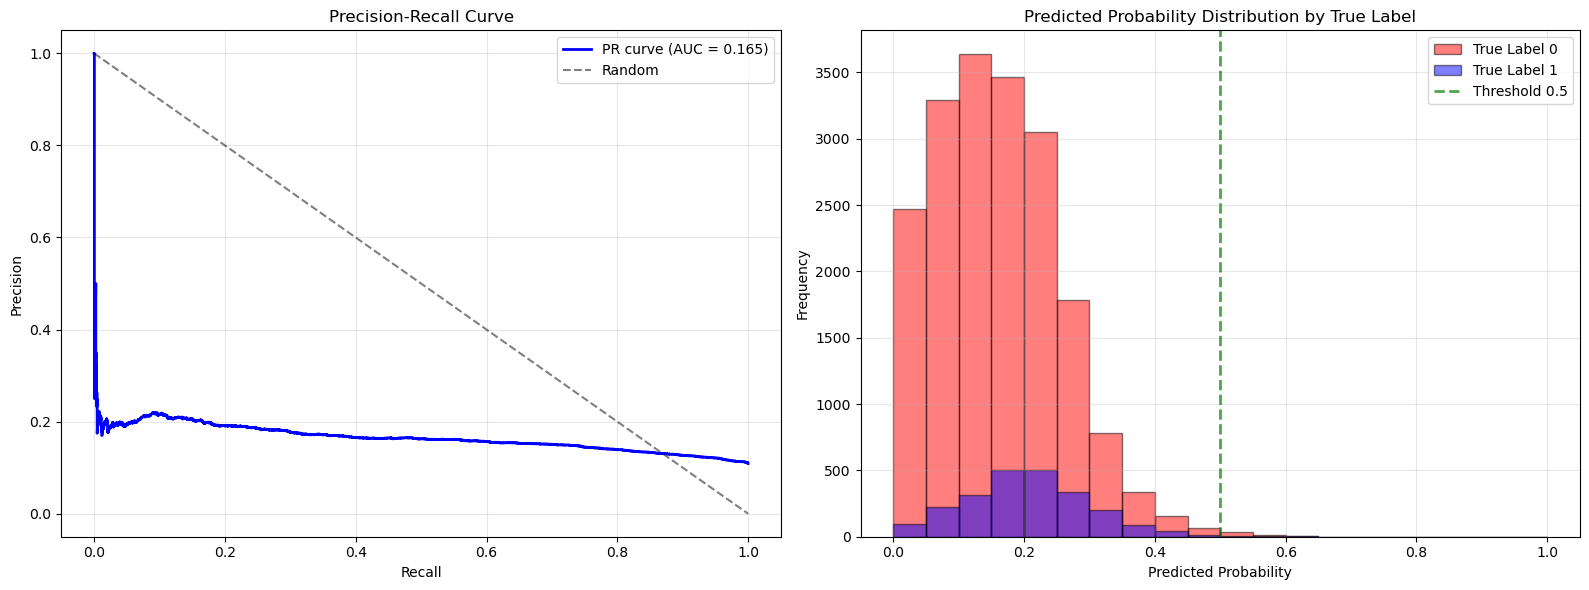

In [28]:
accuracy = evaluate_model(model, X_test, y_test, show_plots=True)

## 创建策略实例

In [9]:
model_path = f"/home/jovyan/work/model/delta_{instrument_id}_dev.pkl"
strategy = StrategyDemo(model_path, param_dict)
print(f"策略已创建: {strategy.name}")

策略已创建: delta_v1_adaptive


## 使用backtesting工具进行回测

In [10]:
# 导入修复的并行回测模块
sys.path.append('/home/jovyan/work/tactics_demo/tools')
from tools.parallel_backtest_simple import run_parallel_backtest
from multi_day_backtest import backtest_summary
# 运行并行回测
result_df = run_parallel_backtest(
    instrument_id=instrument_id,
    start_ymd="20251201",
    end_ymd="20251231",
    StrategyClass=StrategyDemo,
    model=model_path,
    param_dict=param_dict,
    n_cores=4
)


print("\n并行回测结果汇总:")
summary = backtest_summary(result_df)

-> Python解释器: /opt/conda/bin/python
-> Python版本: 3.13.11 | packaged by conda-forge | (main, Jan 26 2026, 23:57:06) [GCC 14.3.0]
spawn模式启动
-> 当前 Python 解释器: /opt/conda/bin/python
-> 从delta/train.py获取到 57 个有数据的交易日
-> 过滤后剩余 23 个有数据的交易日
-> 过滤掉 8 个无数据日期: ['20251206', '20251207', '20251213', '20251214', '20251220', '20251221', '20251227', '20251228']
-> 回测标的: 511090 (20251201 - 20251231)
-> 任务分配: 共 23 天，使用 4 个核心并行计算...


Process SpawnPoolWorker-4:
Process SpawnPoolWorker-1:
Process SpawnPoolWorker-3:
Process SpawnPoolWorker-2:
Traceback (most recent call last):
Traceback (most recent call last):
  File "/opt/conda/lib/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/opt/conda/lib/python3.13/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.13/multiprocessing/pool.py", line 125, in worker
    result = (True, func(*args, **kwds))
                    ~~~~^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.13/multiprocessing/pool.py", line 51, in starmapstar
    return list(itertools.starmap(args[0], args[1]))
  File "/home/jovyan/work/tactics_demo/tools/parallel_backtest_simple.py", line 96, in worker_process
    strategy.on_snap(snap)
    ~~~~~~~~~~~~~~~~^^^^^^
  File "/home/jovyan/work/tactics_demo/delta/strategy.py", line 69, in on_snap


KeyboardInterrupt: 

2883, in inplace_predict
    return _prediction_output(shape, dims, preds, False)
  File "/opt/conda/lib/python3.13/site-packages/xgboost/core.py", line 442, in _prediction_output
    make_array_interface(predts, arr_shape, np.float32, is_cuda)
    ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.13/site-packages/xgboost/_data_utils.py", line 199, in make_array_interface
    addr = ctypes.cast(ptr, ctypes.c_void_p).value
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.13/ctypes/__init__.py", line 538, in cast
    def cast(obj, typ):
    
KeyboardInterrupt


-> Python解释器: /opt/conda/bin/python
-> Python版本: 3.13.11 | packaged by conda-forge | (main, Jan 26 2026, 23:57:06) [GCC 14.3.0]
spawn模式启动
-> 当前 Python 解释器: /opt/conda/bin/python
-> 从delta/train.py获取到 57 个有数据的交易日
-> 过滤后剩余 34 个有数据的交易日
-> 过滤掉 331 个无数据日期: ['20260101', '20260102', '20260103', '20260104', '20260110', '20260111', '20260117', '20260118', '20260124', '20260125']...
-> 回测标的: 511090 (20260101 - 20261231)
-> 任务分配: 共 34 天，使用 4 个核心并行计算...


[SpawnPoolWorker-24] 日期 20260211 完成 | 盈亏: -0.40 | 成交: 12次 | 胜率: 25.0% | 平均持仓: 947.3快照
[SpawnPoolWorker-21] 日期 20260105 完成 | 盈亏: 4.80 | 成交: 10次 | 胜率: 70.0% | 平均持仓: 1143.6快照
[SpawnPoolWorker-23] 日期 20260129 完成 | 盈亏: 1.60 | 成交: 9次 | 胜率: 55.6% | 平均持仓: 1285.0快照
[SpawnPoolWorker-22] 日期 20260116 完成 | 盈亏: -19.60 | 成交: 14次 | 胜率: 28.6% | 平均持仓: 687.4快照
[SpawnPoolWorker-24] 日期 20260212 完成 | 盈亏: -24.40 | 成交: 16次 | 胜率: 12.5% | 平均持仓: 726.0快照
[SpawnPoolWorker-23] 日期 20260130 完成 | 盈亏: 26.70 | 成交: 6次 | 胜率: 50.0% | 平均持仓: 1789.8快照
[SpawnPoolWorker-22] 日期 20260119 完成 | 盈亏: 1.50 | 成交: 11次 | 胜率: 45.5% | 平均持仓: 1026.0快照
[SpawnPoolWorker-21] 日期 20260106 完成 | 盈亏: 36.50 | 成交: 7次 | 胜率: 57.1% | 平均持仓: 1357.6快照
[SpawnPoolWorker-24] 日期 20260213 完成 | 盈亏: 46.80 | 成交: 7次 | 胜率: 57.1% | 平均持仓: 1553.9快照
[SpawnPoolWorker-23] 日期 20260202 完成 | 盈亏: 3.70 | 成交: 12次 | 胜率: 41.7% | 平均持仓: 856.2快照
[SpawnPoolWorker-22] 日期 20260120 完成 | 盈亏: -6.50 | 成交: 12次 | 胜率: 25.0% | 平均持仓: 1011.5快照
[SpawnPoolWorker-21] 日期 20260107 完成 | 盈亏: 53.40 | 成交:

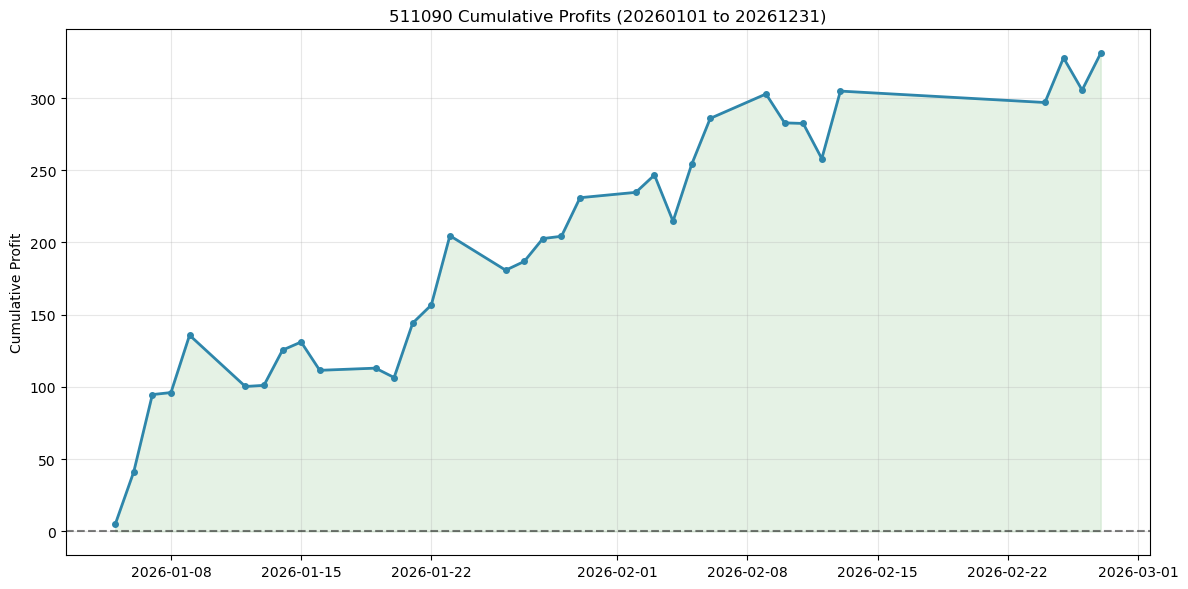


并行回测结果汇总:


In [31]:
# 导入修复的并行回测模块
sys.path.append('/home/jovyan/work/tactics_demo/tools')
from tools.parallel_backtest_simple import run_parallel_backtest
from multi_day_backtest import backtest_summary
# 运行并行回测
result_df = run_parallel_backtest(
    instrument_id=instrument_id,
    start_ymd="20260101",
    end_ymd="20261231",
    StrategyClass=StrategyDemo,
    model=model_path,
    param_dict=param_dict,
    n_cores=4
)


print("\n并行回测结果汇总:")
summary = backtest_summary(result_df)

In [32]:
print(summary)

{'测试天数': 34, '累计总盈亏': np.float64(331.0), '总成交次数': 357, '盈利交易次数': 143, '亏损交易次数': 214, '加权每手胜率%': np.float64(40.06), '日均盈亏': np.float64(9.74), '胜率(天)%': 70.59, '盈亏比(日均)': np.float64(1.13), '最大单日盈利': 53.4, '最大单日亏损': -35.5, '每笔交易平均盈利': np.float64(0.93), '加权平均持仓时间(快照)': np.float64(1075.91)}


## 延迟回测结果

In [ ]:
from delay_stability_test import batch_delay_stability_test
batch_delay_stability_test(
    instrument_id,
    "20251201",
    "20251231",
    StrategyDemo,
    model_path,
    param_dict,
    [0,1,2,4,8,16,32,64,128,256,512,1024],
    
)

## 保存回测结果

In [ ]:
# 导入结果保存工具
from tools.result_saver import save_backtest_results

# 保存回测结果

result_dir = save_backtest_results(
    param_dict=param_dict,
    summary=summary,
    result_df=result_df
)

print(f"回测结果已保存到: {result_dir}")
print("文件夹包含以下文件:")
import os
for file in os.listdir(result_dir):
    print(f"  - {file}")

保存回测结果到: /home/jovyan/work/tactics_demo/backtest_result/511520_delta_v1_adaptive_20260421_031216
回测结果已保存到: /home/jovyan/work/tactics_demo/backtest_result/511520_delta_v1_adaptive_20260421_031216
文件夹包含以下文件:
  - summary.json
  - daily_results.pkl
  - parameters.json
  - daily_results.csv
  - README.md


In [ ]:
from tools import delete_backtest_results_by_date, delete_backtest_results_by_instrument_date
delete_backtest_results_by_date("20260413", dry_run=True)
deleted = delete_backtest_results_by_instrument_date("518880", "20260414", dry_run=False)


[DRY RUN] 总共将删除 0 个文件夹
已删除: /home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_adaptive_20260414_025053
已删除: /home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_adaptive_20260414_042231
已删除: /home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_adaptive_20260414_011936
已删除: /home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_adaptive_20260414_061311

总共删除了 4 个文件夹


## 单日回测观察

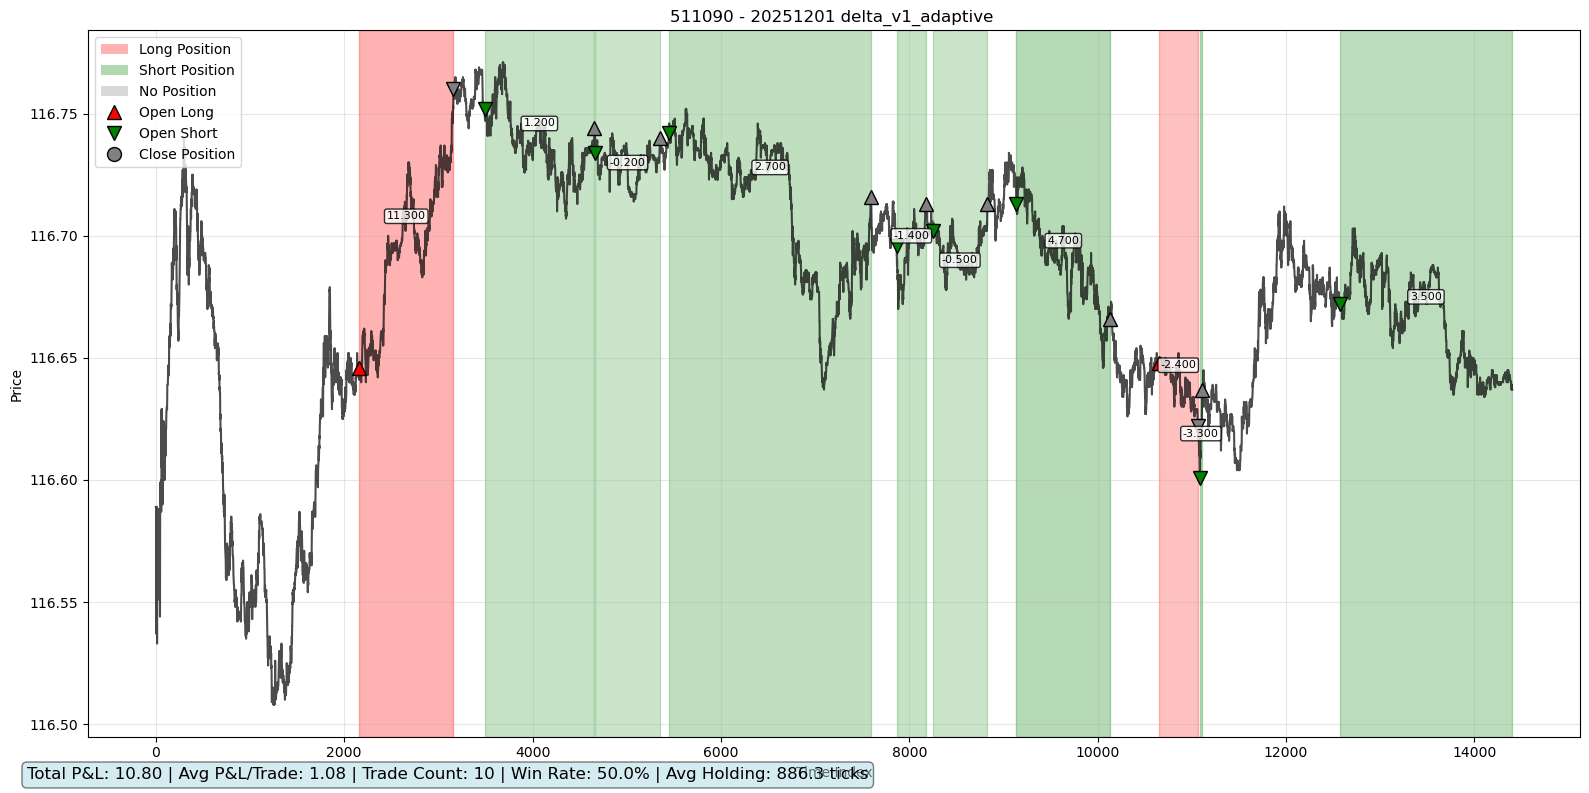

In [11]:
from single_day_backtest import single_day_backtest,plot_delta_history
strategy = StrategyDemo(model_path, param_dict)
hh = single_day_backtest(instrument_id,'20251201',StrategyDemo,model_path,param_dict,official = False)

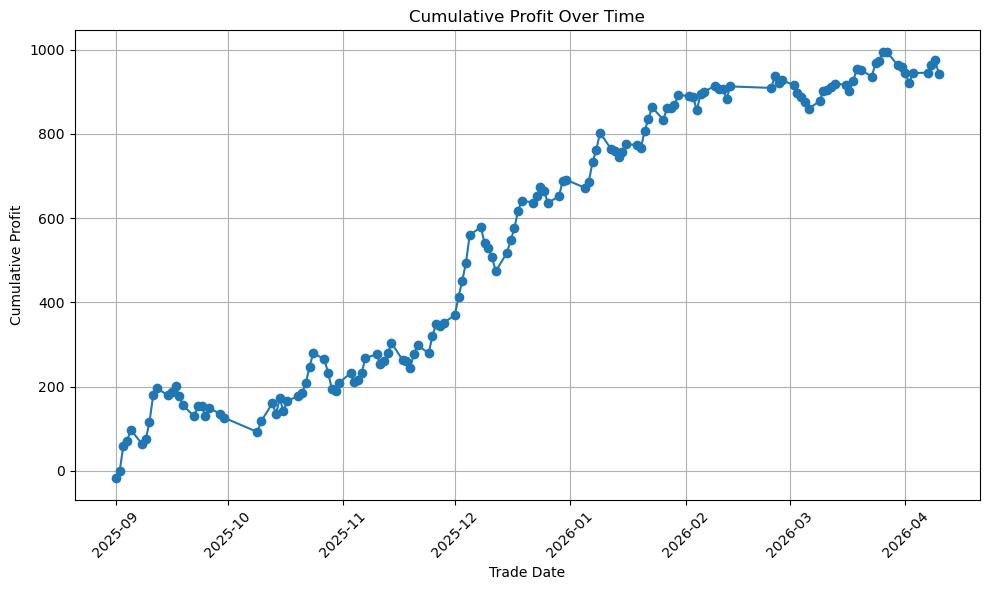

In [34]:
summary = pd.read_csv('/home/jovyan/work/live_trading/511090_20260421_oyyb_01.csv')
# plot cumulative profits

summary['cumulative_profit'] = summary['profits'].cumsum()
summary['trade_ymd'] = pd.to_datetime(summary['trade_ymd'], format='%Y%m%d')
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(summary['trade_ymd'], summary['cumulative_profit'], marker='o')
plt.title('Cumulative Profit Over Time')
plt.xlabel('Trade Date')
plt.ylabel('Cumulative Profit')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()
